In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Milestone 2

This milestone has been created to transition you from classical NLP techniques to modern, state-of-the-art deep learning architectures. It focuses on familiarizing you with the *Hugging Face ecosystem*, understanding how attention mechanisms create *context-aware representations* , and leveraging *pre-trained models* and *zero-shot classification to drastically* improve upon your baseline ranking metrics.


## Imports and other pre work env setup

In [2]:
import numpy as np
import torch
import pandas as pd

import warnings 
warnings.filterwarnings("ignore")

from datasets import load_dataset

from transformers import (AutoTokenizer, AutoModel, pipeline)
from sentence_transformers import(SentenceTransformer, util)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from tqdm.auto import tqdm

In [3]:
from huggingface_hub import scan_cache_dir

try:
    cache = scan_cache_dir()
    print(cache.size_on_disk_str)
except:
    print("Cache will be created automatically.")

Cache will be created automatically.


In [4]:
import datasets
import transformers
import sentence_transformers

print("PyTorch:", torch.__version__)
print("Datasets:", datasets.__version__)
print("Transformers:", transformers.__version__)
print("Sentence Transformers:", sentence_transformers.__version__)

PyTorch: 2.10.0+cpu
Datasets: 4.8.5
Transformers: 5.0.0
Sentence Transformers: 5.4.0


## Introduction to Hugging Face transformers and datasets


In [5]:
dataset = load_dataset("csv", data_files={
    "train": "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv",
    "test": "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
})

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'],
        num_rows: 500
    })
})


In [7]:
train_dataset = dataset["train"]
test_dataset = dataset["test"]

In [8]:
print(train_dataset)

Dataset({
    features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'],
    num_rows: 2000
})


In [9]:
# dataset information
print ("training samples:", len(train_dataset))
print ("test samples:", len(test_dataset))
print("\nTraining Columns:")
print(train_dataset.column_names)

print("\nTesting Columns:")
print(test_dataset.column_names)

training samples: 2000
test samples: 500

Training Columns:
['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']

Testing Columns:
['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


In [10]:
train_dataset[0]

{'id': 1,
 'prompt': "Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.",
 'A': "Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.",
 'B': 'Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.',
 'C': 'Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.',
 'D': 'Martin He

# Introduction to Hugging Face transformers and datasets
## Q1
Load train.csv using the Hugging Face datasets library (do not use pandas). Use the .map() function to create a new column called combined_text that concatenates the prompt and A columns with a space in between. E.g., prompt_text A_text. What is the exact character length (total number of string characters using Python's len() function, NOT the number of tokens) of the combined_text string for the row at index 51? Note: We follow zero-indexing here.

In [11]:
# implementing MAP function 
def combine_prompt_a_column(unite):
    return{"combined_text": unite["prompt"] + " "+ unite["A"]}

train_dataset = train_dataset.map(combine_prompt_a_column)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [12]:
train_dataset.column_names

['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer', 'combined_text']

In [13]:
train_dataset[0]["combined_text"]

"Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time."

In [14]:
merged_text = train_dataset[51]["combined_text"]
print(merged_text)
print(len(merged_text))

Determine the correct option: What is the reason behind the designation of Class L dwarfs, and what is their color and composition? among the listed options. Class L dwarfs are hotter than M stars and are designated L because L is the remaining letter alphabetically closest to M. They are bright blue in color and are brightest in ultraviolet. Their atmosphere is hot enough to allow metal hydrides and alkali metals to be prominent in their spectra. Some of these objects have masses large enough to support hydrogen fusion and are therefore stars, but most are of substellar mass and are therefore brown dwarfs.
614


## Q2

Initialize the bert-base-uncased tokenizer. Look at the tokenizer's configuration properties: what is the exact total vocabulary size (the maximum number of unique subword tokens the model knows) hardcoded into this tokenizer?

In [15]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [16]:
print(tokenizer)
tokenizer.vocab_size

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


30522

In [18]:
print("Vocabulary Size:", tokenizer.vocab_size)

Vocabulary Size: 30522


## Q3
Transformers rely on special tokens to understand sentence boundaries. Using the bert-base-uncased tokenizer from the previous step, extract the exact integer ID assigned to the [SEP] (Separator) token.

In [17]:
print("SEP Token:", tokenizer.sep_token)
print("SEP Token ID:", tokenizer.sep_token_id)

SEP Token: [SEP]
SEP Token ID: 102


In [18]:
#other special token id's
print("CLS Token :", tokenizer.cls_token, "->", tokenizer.cls_token_id)
print("SEP Token :", tokenizer.sep_token, "->", tokenizer.sep_token_id)
print("PAD Token :", tokenizer.pad_token, "->", tokenizer.pad_token_id)
print("UNK Token :", tokenizer.unk_token, "->", tokenizer.unk_token_id)
print("MASK Token:", tokenizer.mask_token, "->", tokenizer.mask_token_id)

CLS Token : [CLS] -> 101
SEP Token : [SEP] -> 102
PAD Token : [PAD] -> 0
UNK Token : [UNK] -> 100
MASK Token: [MASK] -> 103


## Q4
Using the bert-base-uncased tokenizer, tokenize the entire prompt column of the train dataset simultaneously. Set padding='max_length', truncation=True, max_length=128, and return_tensors='pt' (PyTorch tensors). 

What is the exact geometric shape (dimensions) of the resulting input_ids tensor?

In [19]:
prompts = list(train_dataset["prompt"])

In [20]:
tokenized_prompts = tokenizer(
    prompts,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

In [21]:
print(tokenized_prompts["input_ids"].shape)

torch.Size([2000, 128])


# BERT/RoBERTa Architecture & Attention Mechanisms
## Q5

A standard bert-base-uncased model has a hidden embedding size of 768 dimensions and uses exactly 12 attention heads in each layer. 

In Transformer architecture, the hidden size is divided equally among the attention heads. What is the exact dimensionality (size) of each individual attention head?  

>as the hidden embedding size of the model is 768 and uses 12 attention heads in each layer
and each attention heads has the same hidden size then 
Head dimension = 768/12 = 64

## Q7
Load the bert-base-uncased model using AutoModel.from_pretrained(). Tokenize the prompt from row ID 0 using the tokenizer's default settings (do not apply any manual padding or truncation). Pass this tokenized input through the model. Look at the output object.

What is the exact shape of the last_hidden_state tensor returned? 

In [22]:
model_bert = AutoModel.from_pretrained("bert-base-uncased")
model_bert.eval()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [23]:
prompt_eval = train_dataset[0]["prompt"]

In [24]:
inputs = tokenizer(prompt_eval, return_tensors = "pt")

In [25]:
with torch.no_grad():
    outputs = model_bert(**inputs)

print(outputs.last_hidden_state.shape)

torch.Size([1, 31, 768])


## Q8
Using the last_hidden_state tensor from the previous question, extract the embedding vector representing the [CLS] token (which is always the token at index 0). What is the sum of the first 5 float values in this [CLS] vector? (Round your answer to 4 decimal places).  

In [26]:
cls_embedding = outputs.last_hidden_state[0,0]

In [27]:
print(cls_embedding.shape)

torch.Size([768])


In [28]:
#sum of the first 5 float values
print(cls_embedding[:5])
sum_first_five = cls_embedding[:5].sum().item()
print(round(sum_first_five, 4))

tensor([-0.4677, -0.0754, -0.2019, -0.0071, -0.4480])
-1.2001


## Q9
Load bert-base-uncased with the parameter output_attentions=True. Tokenize the exact string "Light-ion fusion is a technique." (ensuring you set return_tensors='pt') and pass it through the model. Extract the attention matrix for the last layer (index -1) and the first attention head (head index 0). 

What is the exact attention weight (a float value) that the [CLS] token (token index 0) pays to the word fusion (you will need to find the specific token index for fusion in the input_ids)? (Round your answer to 4 decimal places).  

In [29]:
model_attention = AutoModel.from_pretrained("bert-base-uncased", output_attentions = True)
model_attention.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [30]:
text_q_eight = "Light-ion fusion is a technique."
inputs = tokenizer(text_q_eight, return_tensors = "pt")

with torch.no_grad():
    outputs = model_attention(**inputs)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
for i, token in enumerate(tokens):
    print(i, token)

fusion_index = tokens.index("fusion")
attention = outputs.attentions[-1][0,0]
cls_to_fusion = attention[0, fusion_index].item()
print(round(cls_to_fusion, 4))

0 [CLS]
1 light
2 -
3 ion
4 fusion
5 is
6 a
7 technique
8 .
9 [SEP]
0.1025


# Context-Aware Embeddings 
## Q10
Initialize the sentence-transformers/all-MiniLM-L6-v2 model. Use the model's .encode() method to generate embeddings for both the prompt and Option B for row ID 0. Calculate the cosine similarity between these two vectors specifically using the sentence_transformers.util.cos_sim() function. What is the resulting similarity score rounded to 4 decimal places? Note: We follow zero-indexing here.

In [31]:
model_mini = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
prompt = train_dataset[0]["prompt"]
option_b = train_dataset[0]["B"]

prompt_embedding = model_mini.encode(prompt, convert_to_tensor = True)
option_b_embedding = model_mini.encode(option_b, convert_to_tensor = True)

similarity = util.cos_sim(prompt_embedding, option_b_embedding)

print(round(similarity.item(), 4))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

0.7658


## Q11
Build two complete ranking pipelines evaluating every row in train.csv.

Pipeline 1: Use the TF-IDF cosine similarity approach from Milestone 1.

Pipeline 2: Use the sentence-transformers/all-MiniLM-L6-v2 model to generate embeddings for the prompt and all five options. Rank options using cosine similarity to form Top-3 predictions.

First, what is the final MAP@3 score of the all-MiniLM-L6-v2 pipeline across the entire training set? 

Second, count the number of questions for which the correct answer is NOT present in the TF-IDF Top-3 predictions BUT IS present in the MiniLM Top-3 predictions. What is this exact resulting count?  

In [32]:
def apk(actual, predicted, k=3):
    predicted = predicted[:k]

    if actual in predicted:
        return 1.0 / (predicted.index(actual) + 1)

    return 0.0


def mapk(actuals, predictions, k=3):
    scores = [apk(actual, prediction, k)
        for actual, prediction in zip(actuals, predictions)
    ]

    return np.mean(scores)

In [34]:
def rank_top3(similarity_score):
    ranked_options = sorted(similarity_score.items(), key = lambda item: item[1], reverse = True)
    return [option for option, _ in ranked_options[:3]]

In [35]:
def tfidf_rank(prompt, options):
    texts_tf = [prompt] + list(options.values())
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts_tf)

    prompt_vector = tfidf_matrix[0]
    option_vectors = tfidf_matrix[1:]
    similarities = cosine_similarity(prompt_vector, option_vectors)[0]
    similarity_scores = {label: score
                         for label, score in zip(options.keys(), similarities)}
    return rank_top3(similarity_scores)

In [36]:
tfidf_predictions = []
actual_answers = []

for example in tqdm(train_dataset, desc="TF-IDF Evaluation"):
    
    options = {
        "A": example["A"],
        "B": example["B"],
        "C": example["C"],
        "D": example["D"],
        "E": example["E"],
    }

    prediction = tfidf_rank(
        example["prompt"],
        options
    )

    tfidf_predictions.append(prediction)
    actual_answers.append(example["answer"])

TF-IDF Evaluation:   0%|          | 0/2000 [00:00<?, ?it/s]

In [37]:
tfidf_map3 = mapk(actual_answers, tfidf_predictions, k=3)

print(f"TF-IDF MAP@3: {tfidf_map3:.4f}")

TF-IDF MAP@3: 0.3448


In [38]:
# minilm part

def minilm_rank(prompt, options):
    texts = [prompt] + list(options.values())
    embeddings = model_mini.encode(texts, convert_to_tensor = True)
    prompt_embedding = embeddings[0]
    option_embeddings = embeddings[1:]
    similarities = util.cos_sim(prompt_embedding, option_embeddings)[0]
    similarity_scores = {label: score.item()
                        for label, score in zip(options.keys(), similarities)}
    return rank_top3(similarity_scores)

In [39]:
minilm_predictions = []

for example in tqdm(train_dataset, desc="MiniLM Evaluation"):

    options = {
        "A": example["A"],
        "B": example["B"],
        "C": example["C"],
        "D": example["D"],
        "E": example["E"],
    }

    prediction = minilm_rank(
        example["prompt"],
        options
    )

    minilm_predictions.append(prediction)

MiniLM Evaluation:   0%|          | 0/2000 [00:00<?, ?it/s]

In [40]:
minilm_map3 = mapk(
    actual_answers,
    minilm_predictions,
    k=3
)

print(f"MiniLM MAP@3: {minilm_map3:.4f}")

MiniLM MAP@3: 0.4231


In [41]:
improved_count = 0

for actual, tfidf_pred, minilm_pred in zip(
    actual_answers,
    tfidf_predictions,
    minilm_predictions
):
    if actual not in tfidf_pred and actual in minilm_pred:
        improved_count += 1

print(f"Improved Questions: {improved_count}")

Improved Questions: 513


# Zero-shot classification concepts 
## Q12

Initialize the Hugging Face pipeline for "zero-shot-classification" (it will default to facebook/bart-large-mnli). For the prompt of the 2nd row (index 1), pass Options A, B, and C as the candidate_labels. What is the probability score given to the top-ranked option? (Round to 4 decimal places).
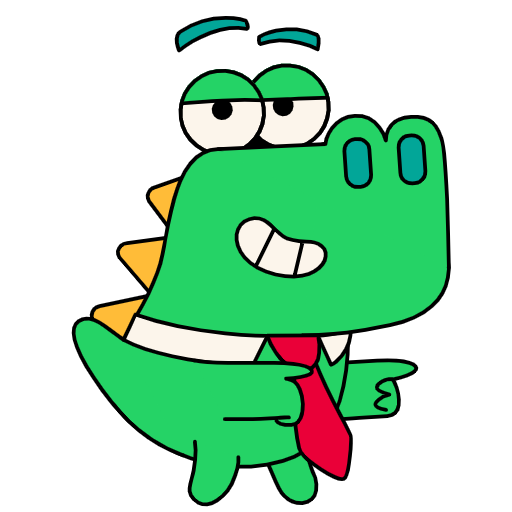

In [42]:
zero_shot = pipeline("zero-shot-classification")
prompt = train_dataset[1]["prompt"]

candidate_labels = [train_dataset[1]["A"],train_dataset[1]["B"],train_dataset[1]["C"]]
result = zero_shot(prompt, candidate_labels)
print(result)

top_probability = result["scores"][0]

print(round(top_probability, 4))

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'sequence': 'What is accelerator-based light-ion fusion?', 'labels': ['Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 100 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion

Run the exact same zero-shot classification as the previous question, but this time pass the argument multi_label=True. 

What is the absolute difference between the sum of the 3 probabilities in the previous question (which uses Softmax) and the sum of the 3 probabilities in this question (which uses independent Sigmoids)?

In [43]:
result_multi = zero_shot(prompt, candidate_labels, multi_label = True)
print(result_multi)
softmax_sum = sum(result["scores"])
sigmoid_sum = sum(result_multi["scores"])
difference = abs(softmax_sum - sigmoid_sum)
print(round(difference, 4))

{'sequence': 'What is accelerator-based light-ion fusion?', 'labels': ['Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion 

# Generative AI instead of Classification. 
## Q13

Load a Small Language Model like google/flan-t5-small using the Hugging Face pipeline("text2text-generation"). Construct the following exact string for row index 0: "Question: [prompt]. Is the correct answer A: [A] or B: [B]? Answer with just the letter A or B." 
Pass this string to the pipeline, setting max_new_tokens=5. What is the exact string output returned by the model?

In [44]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_name = "google/flan-t5-small"

tokenizer_t5 = AutoTokenizer.from_pretrained(model_name)
model_t5 = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [45]:
generator = pipeline(
    "text-generation",
    model="google/flan-t5-small",
    tokenizer=tokenizer_t5
)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

In [46]:
prompt = train_dataset[0]["prompt"]
option_a = train_dataset[0]["A"]
option_b = train_dataset[0]["B"]

input_text = (
    f"Question: {prompt}. "
    f"Is the correct answer A: {option_a} "
    f"or B: {option_b}? "
    f"Answer with just the letter A or B."
)

inputs = tokenizer_t5(input_text,return_tensors="pt")

outputs = model_t5.generate(**inputs,max_new_tokens=5)

generated_text = tokenizer_t5.decode(outputs[0],skip_special_tokens=True)

print(generated_text)

B
